In [4]:
# ============================================================
# ECOPLATE - CELL 1
# Import Libraries
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 70)
print("ECOPLATE - LIBRARIES LOADED")
print("=" * 70)
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)

ECOPLATE - LIBRARIES LOADED
TensorFlow version: 2.21.0
NumPy version: 2.3.5
Pandas version: 2.3.3


In [5]:
# ============================================================
# ECOPLATE - CELL 2
# Load Restaurant and NGO Datasets
# ============================================================

RESTAURANT_FILE = "EcoPlate_Cleaned.csv"
NGO_FILE = "NGO_Cleaned.csv"

restaurant_df = pd.read_csv(RESTAURANT_FILE)
ngo_df = pd.read_csv(NGO_FILE)

print("=" * 70)
print("DATASET LOADING")
print("=" * 70)

print("Restaurant dataset shape:", restaurant_df.shape)
print("NGO dataset shape:", ngo_df.shape)

print("\nRestaurant columns:")
print(list(restaurant_df.columns))

print("\nNGO columns:")
print(list(ngo_df.columns))

DATASET LOADING
Restaurant dataset shape: (11493, 16)
NGO dataset shape: (15, 11)

Restaurant columns:
['Date', 'Day_of_Week', 'Month', 'Restaurant_Name', 'Menu_Item', 'Weather', 'Is_Holiday', 'Festival', 'Reservations', 'Walk_In_Customers', 'Previous_Day_Sales', 'Avg_Last_7_Days', 'Quantity_Prepared', 'Quantity_Sold', 'Leftover', 'Calculated_Leftover']

NGO columns:
['NGO_ID', 'NGO_Name', 'Area', 'Latitude', 'Longitude', 'Capacity_Meals', 'Food_Type_Accepted', 'Pickup_Start', 'Pickup_End', 'Availability', 'Contact_Number']


In [7]:
# ============================================================
# ECOPLATE - CELL 3
# Data Cleaning - CORRECTED
# ============================================================

df = restaurant_df.copy()
ngo = ngo_df.copy()

# ------------------------------------------------------------
# 1. Convert Date
# ------------------------------------------------------------

df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# ------------------------------------------------------------
# 2. Clean categorical columns
# ------------------------------------------------------------

categorical_columns = [
    "Day_of_Week",
    "Restaurant_Name",
    "Menu_Item",
    "Weather",
    "Festival"
]

for col in categorical_columns:
    df[col] = (
        df[col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

# ------------------------------------------------------------
# 3. Convert Is_Holiday correctly
# Handles Yes / No, True / False, 1 / 0
# ------------------------------------------------------------

df["Is_Holiday"] = (
    df["Is_Holiday"]
    .fillna("No")
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "yes": 1,
        "no": 0,
        "true": 1,
        "false": 0,
        "1": 1,
        "0": 0
    })
    .fillna(0)
    .astype(int)
)

# ------------------------------------------------------------
# 4. Numerical columns
# ------------------------------------------------------------

numeric_columns = [
    "Reservations",
    "Walk_In_Customers",
    "Previous_Day_Sales",
    "Avg_Last_7_Days",
    "Quantity_Prepared",
    "Quantity_Sold",
    "Leftover"
]

for col in numeric_columns:
    
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Fill numerical missing values
for col in numeric_columns:
    
    df[col] = df[col].fillna(0)

# ------------------------------------------------------------
# 5. Remove invalid dates
# ------------------------------------------------------------

df = df.dropna(
    subset=["Date"]
)

# ------------------------------------------------------------
# 6. Remove duplicate rows
# ------------------------------------------------------------

df = df.drop_duplicates()

# ------------------------------------------------------------
# 7. Sort data chronologically
# ------------------------------------------------------------

df = df.sort_values(
    ["Restaurant_Name", "Menu_Item", "Date"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 8. Final result
# ------------------------------------------------------------

print("=" * 70)
print("DATA CLEANING RESULT")
print("=" * 70)

print("Final restaurant records :", len(df))
print("Number of columns        :", len(df.columns))

print(
    "Missing values           :",
    int(df.isnull().sum().sum())
)

print(
    "Duplicate rows           :",
    int(df.duplicated().sum())
)

print("\nIs_Holiday values after conversion:")
print(
    df["Is_Holiday"].value_counts().sort_index()
)

print("\nDate range:")
print(
    df["Date"].min(),
    "to",
    df["Date"].max()
)

print("\nFirst 5 records:")
display(df.head())

DATA CLEANING RESULT
Final restaurant records : 11493
Number of columns        : 16
Missing values           : 0
Duplicate rows           : 0

Is_Holiday values after conversion:
Is_Holiday
0    11133
1      360
Name: count, dtype: int64

Date range:
2025-01-01 00:00:00 to 2025-12-16 00:00:00

First 5 records:


,Date,Day_of_Week,Month,Restaurant_Name,Menu_Item,Weather,Is_Holiday,Festival,Reservations,Walk_In_Customers,Previous_Day_Sales,Avg_Last_7_Days,Quantity_Prepared,Quantity_Sold,Leftover,Calculated_Leftover
0,2025-01-01,Wednesday,January,Aroma Kitchen,Butter Chicken,Sunny,1,New Year,39.0,70.0,102.0,111.0,130.0,118.0,12.0,12.0
1,2025-01-02,Thursday,January,Aroma Kitchen,Butter Chicken,Sunny,0,No_Festival,50.0,90.0,130.0,133.0,150.0,132.0,18.0,18.0
2,2025-01-03,Friday,January,Aroma Kitchen,Butter Chicken,Cloudy,0,No_Festival,40.0,73.0,109.0,114.0,131.0,123.0,8.0,8.0
3,2025-01-04,Saturday,January,Aroma Kitchen,Butter Chicken,Cloudy,0,No_Festival,56.0,115.0,178.0,184.0,213.0,183.0,30.0,30.0
4,2025-01-05,Sunday,January,Aroma Kitchen,Butter Chicken,Stormy,0,No_Festival,38.0,76.0,94.0,98.0,114.0,106.0,8.0,8.0


In [8]:
# ============================================================
# ECOPLATE - CELL 4
# Feature Engineering
# ============================================================

df["Day_Number"] = df["Date"].dt.day
df["Year"] = df["Date"].dt.year

# Weekend indicator
df["Is_Weekend"] = df["Date"].dt.dayofweek.isin([5, 6]).astype(int)

# Month number
df["Month_Number"] = df["Date"].dt.month

# Week number
df["Week_Number"] = df["Date"].dt.isocalendar().week.astype(int)

# Target
TARGET = "Quantity_Sold"

print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

print("Target variable:", TARGET)

print("\nNew features:")
print([
    "Day_Number",
    "Year",
    "Is_Weekend",
    "Month_Number",
    "Week_Number"
])

display(df.head())

FEATURE ENGINEERING
Target variable: Quantity_Sold

New features:
['Day_Number', 'Year', 'Is_Weekend', 'Month_Number', 'Week_Number']


,Date,Day_of_Week,Month,Restaurant_Name,Menu_Item,Weather,Is_Holiday,Festival,Reservations,Walk_In_Customers,...,Avg_Last_7_Days,Quantity_Prepared,Quantity_Sold,Leftover,Calculated_Leftover,Day_Number,Year,Is_Weekend,Month_Number,Week_Number
0,2025-01-01,Wednesday,January,Aroma Kitchen,Butter Chicken,Sunny,1,New Year,39.0,70.0,...,111.0,130.0,118.0,12.0,12.0,1,2025,0,1,1
1,2025-01-02,Thursday,January,Aroma Kitchen,Butter Chicken,Sunny,0,No_Festival,50.0,90.0,...,133.0,150.0,132.0,18.0,18.0,2,2025,0,1,1
2,2025-01-03,Friday,January,Aroma Kitchen,Butter Chicken,Cloudy,0,No_Festival,40.0,73.0,...,114.0,131.0,123.0,8.0,8.0,3,2025,0,1,1
3,2025-01-04,Saturday,January,Aroma Kitchen,Butter Chicken,Cloudy,0,No_Festival,56.0,115.0,...,184.0,213.0,183.0,30.0,30.0,4,2025,1,1,1
4,2025-01-05,Sunday,January,Aroma Kitchen,Butter Chicken,Stormy,0,No_Festival,38.0,76.0,...,98.0,114.0,106.0,8.0,8.0,5,2025,1,1,1


In [9]:
# ============================================================
# ECOPLATE - CELL 5
# Dataset Statistics
# ============================================================

print("=" * 70)
print("DATASET STATISTICS")
print("=" * 70)

print("Number of restaurants:", df["Restaurant_Name"].nunique())
print("Number of menu items:", df["Menu_Item"].nunique())
print("Number of weather categories:", df["Weather"].nunique())
print("Number of festivals:", df["Festival"].nunique())

print("\nTarget statistics:")
display(df[TARGET].describe().to_frame())

print("\nRestaurant count:")
display(
    df["Restaurant_Name"]
    .value_counts()
    .rename("Records")
    .to_frame()
)

DATASET STATISTICS
Number of restaurants: 10
Number of menu items: 6
Number of weather categories: 4
Number of festivals: 7

Target statistics:


,Quantity_Sold
count,11493.000000
mean,116.391456
std,34.125197
min,38.000000
25%,92.000000
50%,112.000000
75%,137.000000
max,268.000000



Restaurant count:


,Records
Restaurant_Name,
Aroma Kitchen,1152
Curry Corner,1152
Flavor House,1152
Food Junction,1152
Grand Dine,1152
Heritage Grill,1149
Royal Feast,1146
Saffron Bowl,1146
Spice Hub,1146


In [10]:
# ============================================================
# ECOPLATE - CELL 6
# Chronological Train / Validation / Test Split(future information should not be used to train the model)
# ============================================================

unique_dates = sorted(df["Date"].unique())

train_end = int(len(unique_dates) * 0.70)
validation_end = int(len(unique_dates) * 0.85)

train_dates = unique_dates[:train_end]
validation_dates = unique_dates[train_end:validation_end]
test_dates = unique_dates[validation_end:]

train_df = df[df["Date"].isin(train_dates)].copy()
validation_df = df[df["Date"].isin(validation_dates)].copy()
test_df = df[df["Date"].isin(test_dates)].copy()

print("=" * 70)
print("CHRONOLOGICAL DATA SPLIT")
print("=" * 70)

print("Training records   :", len(train_df))
print("Validation records :", len(validation_df))
print("Testing records    :", len(test_df))

print("\nTraining period:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nValidation period:")
print(validation_df["Date"].min(), "to", validation_df["Date"].max())

print("\nTesting period:")
print(test_df["Date"].min(), "to", test_df["Date"].max())

CHRONOLOGICAL DATA SPLIT
Training records   : 8040
Validation records : 1740
Testing records    : 1713

Training period:
2025-01-01 00:00:00 to 2025-09-06 00:00:00

Validation period:
2025-09-07 00:00:00 to 2025-11-03 00:00:00

Testing period:
2025-11-04 00:00:00 to 2025-12-16 00:00:00


In [11]:
# ============================================================
# ECOPLATE - CELL 7
# Categorical Encoding(code converts categories into integer IDs.)
# ============================================================

categorical_features = [
    "Restaurant_Name",
    "Menu_Item",
    "Day_of_Week",
    "Weather",
    "Festival"
]

# Create dictionaries using training data only
category_maps = {}

for col in categorical_features:
    values = sorted(train_df[col].astype(str).unique())
    
    mapping = {
        value: index + 1
        for index, value in enumerate(values)
    }
    
    category_maps[col] = mapping

def encode_categories(data):
    encoded = data.copy()
    
    for col in categorical_features:
        mapping = category_maps[col]
        encoded[col + "_ID"] = (
            encoded[col]
            .astype(str)
            .map(mapping)
            .fillna(0)
            .astype(int)
        )
    
    return encoded

train_encoded = encode_categories(train_df)
validation_encoded = encode_categories(validation_df)
test_encoded = encode_categories(test_df)

print("=" * 70)
print("CATEGORICAL ENCODING")
print("=" * 70)

for col in categorical_features:
    print(
        col,
        "->",
        len(category_maps[col]),
        "categories"
    )

CATEGORICAL ENCODING
Restaurant_Name -> 10 categories
Menu_Item -> 6 categories
Day_of_Week -> 7 categories
Weather -> 4 categories
Festival -> 5 categories


In [12]:
# ============================================================
# ECOPLATE - CELL 8
# Numerical Feature Preparation(prevents features with larger numerical ranges from dominating the neural network.)
# ============================================================

numerical_features = [
    "Reservations",
    "Walk_In_Customers",
    "Previous_Day_Sales",
    "Avg_Last_7_Days",
    "Is_Holiday",
    "Is_Weekend",
    "Month_Number",
    "Day_Number",
    "Week_Number"
]

scaler = StandardScaler()

train_encoded[numerical_features] = scaler.fit_transform(
    train_encoded[numerical_features]
)

validation_encoded[numerical_features] = scaler.transform(
    validation_encoded[numerical_features]
)

test_encoded[numerical_features] = scaler.transform(
    test_encoded[numerical_features]
)

print("=" * 70)
print("NUMERICAL FEATURES NORMALIZED")
print("=" * 70)

display(
    train_encoded[numerical_features].head()
)

NUMERICAL FEATURES NORMALIZED


,Reservations,Walk_In_Customers,Previous_Day_Sales,Avg_Last_7_Days,Is_Holiday,Is_Weekend,Month_Number,Day_Number,Week_Number
0,-0.067817,-0.078950,-0.059233,0.042861,5.700877,-0.640723,-1.526334,-1.569267,-1.608581
1,0.735306,0.789990,0.762059,0.691271,-0.175412,-0.640723,-1.526334,-1.353594,-1.608581
2,0.005194,0.051391,0.146090,0.131280,-0.175412,-0.640723,-1.526334,-1.137920,-1.608581
3,1.173373,1.876165,2.169988,2.194403,-0.175412,1.560736,-1.526334,-0.922246,-1.608581
4,-0.140828,0.181732,-0.293888,-0.340291,-0.175412,1.560736,-1.526334,-0.706573,-1.608581


In [13]:
# ============================================================
# ECOPLATE - CELL 9
# Temporal Sequence Creation(model uses the previous 7 observations to predict the next demand.)
# ============================================================

SEQUENCE_LENGTH = 7

sequence_features = [
    "Restaurant_Name_ID",
    "Menu_Item_ID",
    "Day_of_Week_ID",
    "Weather_ID",
    "Festival_ID",
    "Reservations",
    "Walk_In_Customers",
    "Previous_Day_Sales",
    "Avg_Last_7_Days",
    "Is_Holiday",
    "Is_Weekend",
    "Month_Number",
    "Day_Number",
    "Week_Number"
]

def create_sequences(data, sequence_length=7):
    
    data = data.sort_values(
        ["Restaurant_Name", "Menu_Item", "Date"]
    ).reset_index(drop=True)
    
    X = []
    y = []
    dates = []
    restaurants = []
    items = []
    
    for (restaurant, item), group in data.groupby(
        ["Restaurant_Name", "Menu_Item"]
    ):
        
        group = group.sort_values("Date").reset_index(drop=True)
        
        if len(group) <= sequence_length:
            continue
        
        feature_values = group[sequence_features].values
        target_values = group[TARGET].values
        
        for i in range(sequence_length, len(group)):
            
            X.append(
                feature_values[
                    i-sequence_length:i
                ]
            )
            
            y.append(target_values[i])
            dates.append(group.loc[i, "Date"])
            restaurants.append(restaurant)
            items.append(item)
    
    return (
        np.array(X, dtype=np.float32),
        np.array(y, dtype=np.float32),
        np.array(dates),
        np.array(restaurants),
        np.array(items)
    )

X_train, y_train, train_seq_dates, train_seq_restaurants, train_seq_items = create_sequences(
    train_encoded,
    SEQUENCE_LENGTH
)

X_val, y_val, val_seq_dates, val_seq_restaurants, val_seq_items = create_sequences(
    validation_encoded,
    SEQUENCE_LENGTH
)

X_test, y_test, test_seq_dates, test_seq_restaurants, test_seq_items = create_sequences(
    test_encoded,
    SEQUENCE_LENGTH
)

print("=" * 70)
print("TEMPORAL SEQUENCES")
print("=" * 70)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_validation:", X_val.shape)
print("y_validation:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

TEMPORAL SEQUENCES
X_train: (7620, 7, 14)
y_train: (7620,)
X_validation: (1320, 7, 14)
y_validation: (1320,)
X_test: (1293, 7, 14)
y_test: (1293,)


In [14]:
# ============================================================
# ECOPLATE - CELL 10
# Prepare Neural Network Inputs(separates the temporal sequence into categorical and numerical inputs)
# ============================================================

# Categorical feature positions
categorical_positions = [0, 1, 2, 3, 4]

# Numerical feature positions
numerical_positions = list(range(5, len(sequence_features)))

X_train_cat = X_train[:, :, categorical_positions].astype(np.int32)
X_val_cat = X_val[:, :, categorical_positions].astype(np.int32)
X_test_cat = X_test[:, :, categorical_positions].astype(np.int32)

X_train_num = X_train[:, :, numerical_positions].astype(np.float32)
X_val_num = X_val[:, :, numerical_positions].astype(np.float32)
X_test_num = X_test[:, :, numerical_positions].astype(np.float32)

print("=" * 70)
print("MODEL INPUTS")
print("=" * 70)

print("Categorical input:", X_train_cat.shape)
print("Numerical input:", X_train_num.shape)
print("Target:", y_train.shape)

MODEL INPUTS
Categorical input: (7620, 7, 5)
Numerical input: (7620, 7, 9)
Target: (7620,)


In [15]:
# ============================================================
# ECOPLATE - CELL 11
# Proposed Neural Network(Categorical features are converted into embeddings,)
# Embedding + Multi-Head Attention + Gated Temporal Layer
# ============================================================

from tensorflow.keras.layers import (
    Input,
    Embedding,
    Dense,
    Concatenate,
    MultiHeadAttention,
    LayerNormalization,
    Dropout,
    GRU,
    GlobalAveragePooling1D
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


sequence_input_cat = Input(
    shape=(SEQUENCE_LENGTH, len(categorical_positions)),
    dtype=tf.int32,
    name="categorical_input"
)

sequence_input_num = Input(
    shape=(SEQUENCE_LENGTH, len(numerical_positions)),
    dtype=tf.float32,
    name="numerical_input"
)


# ------------------------------------------------------------
# Categorical embeddings
# ------------------------------------------------------------

embedding_outputs = []

embedding_sizes = []

for i, col in enumerate(categorical_features):
    
    vocabulary_size = len(category_maps[col]) + 1
    
    embedding_dim = min(
        16,
        max(4, int(np.sqrt(vocabulary_size) * 2))
    )
    
    embedding_sizes.append(embedding_dim)
    
    emb = Embedding(
        input_dim=vocabulary_size,
        output_dim=embedding_dim,
        name=f"{col}_embedding"
    )(
        sequence_input_cat[:, :, i]
    )
    
    embedding_outputs.append(emb)


# Combine categorical embeddings
categorical_embedding = Concatenate(
    axis=-1,
    name="categorical_embedding"
)(embedding_outputs)


# ------------------------------------------------------------
# Numerical feature projection
# ------------------------------------------------------------

numerical_projection = Dense(
    32,
    activation="relu",
    name="numerical_projection"
)(sequence_input_num)


# ------------------------------------------------------------
# Combine categorical + numerical
# ------------------------------------------------------------

combined = Concatenate(
    axis=-1,
    name="feature_fusion"
)([
    categorical_embedding,
    numerical_projection
])


# ------------------------------------------------------------
# Multi-Head Self Attention
# ------------------------------------------------------------

attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=16,
    dropout=0.10,
    name="multi_head_attention"
)(
    combined,
    combined
)

attention_output = LayerNormalization(
    name="attention_normalization"
)(
    combined + attention_output
)

attention_output = Dropout(
    0.10
)(attention_output)


# ------------------------------------------------------------
# Gated Temporal Layer
# GRU is used as the gated temporal mechanism
# ------------------------------------------------------------

temporal_output = GRU(
    64,
    return_sequences=True,
    dropout=0.10,
    name="gated_temporal_layer"
)(attention_output)


temporal_output = GRU(
    32,
    return_sequences=False,
    dropout=0.10,
    name="temporal_compression"
)(temporal_output)


# ------------------------------------------------------------
# Prediction Head
# ------------------------------------------------------------

dense_output = Dense(
    32,
    activation="relu"
)(temporal_output)

dense_output = Dropout(0.10)(dense_output)

demand_output = Dense(
    1,
    activation="linear",
    name="demand_prediction"
)(dense_output)


model = Model(
    inputs=[
        sequence_input_cat,
        sequence_input_num
    ],
    outputs=demand_output,
    name="EcoPlate_Attention_Gated_Network"
)


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)


print("=" * 70)
print("ECOPLATE PROPOSED MODEL")
print("=" * 70)

model.summary()

ECOPLATE PROPOSED MODEL


Model: "EcoPlate_Attention_Gated_Network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ categorical_input   │ (None, 7, 5)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 7)         │          0 │ categorical_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 7)         │          0 │ categorical_inpu… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 7)         │          0 │ categorical_inpu… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 7)         │          0 │ categorical_inpu… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 7)         │          0 │ categorical_inpu… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Restaurant_Name_em… │ (None, 7, 6)      │         66 │ get_item[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Menu_Item_embedding │ (None, 7, 5)      │         35 │ get_item_1[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Day_of_Week_embedd… │ (None, 7, 5)      │         40 │ get_item_2[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Weather_embedding   │ (None, 7, 4)      │         20 │ get_item_3[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Festival_embedding  │ (None, 7, 4)      │         24 │ get_item_4[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_input     │ (None, 7, 9)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ categorical_embedd… │ (None, 7, 24)     │          0 │ Restaurant_Name_… │
│ (Concatenate)       │                   │            │ Menu_Item_embedd… │
│                     │                   │            │ Day_of_Week_embe… │
│                     │                   │            │ Weather_embeddin… │
│                     │                   │            │ Festival_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numerical_projecti… │ (None, 7, 32)     │        320 │ numerical_input[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 7, 56)     │          0 │ categorical_embe… │
│ (Concatenate)       │                   │            │ numerical_projec… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 7, 56)     │     14,584 │ feature_fusion[0… │
│ (MultiHeadAttentio… │                   │            │ feature_fusion[0

 Total params: 49,122 (191.88 KB)

 Trainable params: 49,122 (191.88 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# ============================================================
# ECOPLATE - CELL 12
# Model Training(trains the proposed neural network using the training data)
# ============================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=0.00001,
    verbose=1
)

print("=" * 70)
print("TRAINING ECOPLATE NEURAL NETWORK")
print("=" * 70)

history = model.fit(
    [
        X_train_cat,
        X_train_num
    ],
    y_train,
    validation_data=(
        [
            X_val_cat,
            X_val_num
        ],
        y_val
    ),
    epochs=50,
    batch_size=64,
    callbacks=[
        early_stopping,
        reduce_lr
    ],
    verbose=1
)

TRAINING ECOPLATE NEURAL NETWORK
Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 522.5913 - mae: 18.3740 - val_loss: 511.5892 - val_mae: 18.2799 - learning_rate: 2.5000e-04
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 511.6502 - mae: 18.1783 - val_loss: 509.3567 - val_mae: 18.2664 - learning_rate: 2.5000e-04
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 511.0521 - mae: 18.1631 - val_loss: 519.1531 - val_mae: 18.3815 - learning_rate: 2.5000e-04
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 513.6219 - mae: 18.1971 - val_loss: 518.2825 - val_mae: 18.4418 - learning_rate: 2.5000e-04
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 509.0011 - mae: 18.2084 - val_loss: 520.8392 - val_mae: 18.4421 - learning_rate: 2.5000e-04
Epoch 6/50
118/120 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 510.8665 - mae: 18.1581
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step

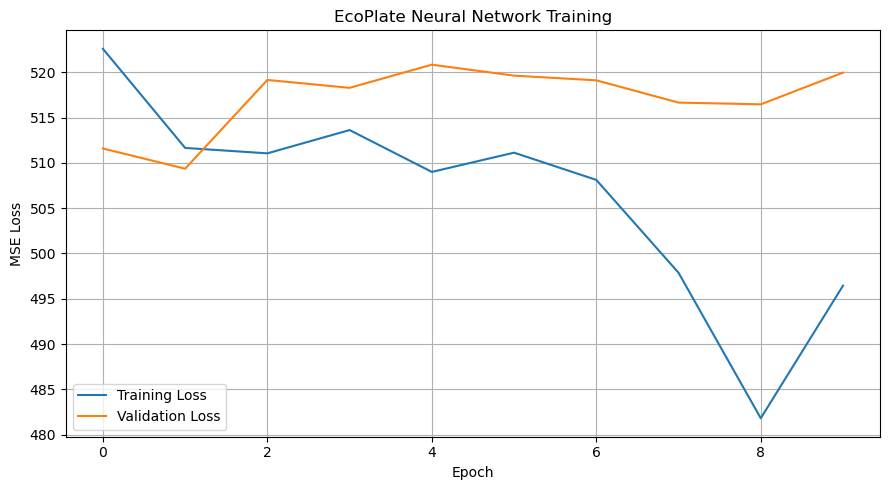

In [45]:
# ============================================================
# ECOPLATE - CELL 13
# Training and Validation Loss(visualizes training and validation loss)
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("EcoPlate Neural Network Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# ECOPLATE - CELL 14
# Test Prediction
# ============================================================

y_pred_ecoplate = model.predict(
    [
        X_test_cat,
        X_test_num
    ],
    verbose=0
).reshape(-1)

# Demand cannot be negative
y_pred_ecoplate = np.maximum(
    y_pred_ecoplate,
    0
)

mae_ecoplate = mean_absolute_error(
    y_test,
    y_pred_ecoplate
)

rmse_ecoplate = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_ecoplate
    )
)

r2_ecoplate = r2_score(
    y_test,
    y_pred_ecoplate
)

print("=" * 70)
print("ECOPLATE TEST RESULTS")
print("=" * 70)

print("MAE  :", round(mae_ecoplate, 3))
print("RMSE :", round(rmse_ecoplate, 3))
print("R²   :", round(r2_ecoplate, 3))

ECOPLATE TEST RESULTS
MAE  : 17.534
RMSE : 21.339
R²   : 0.606


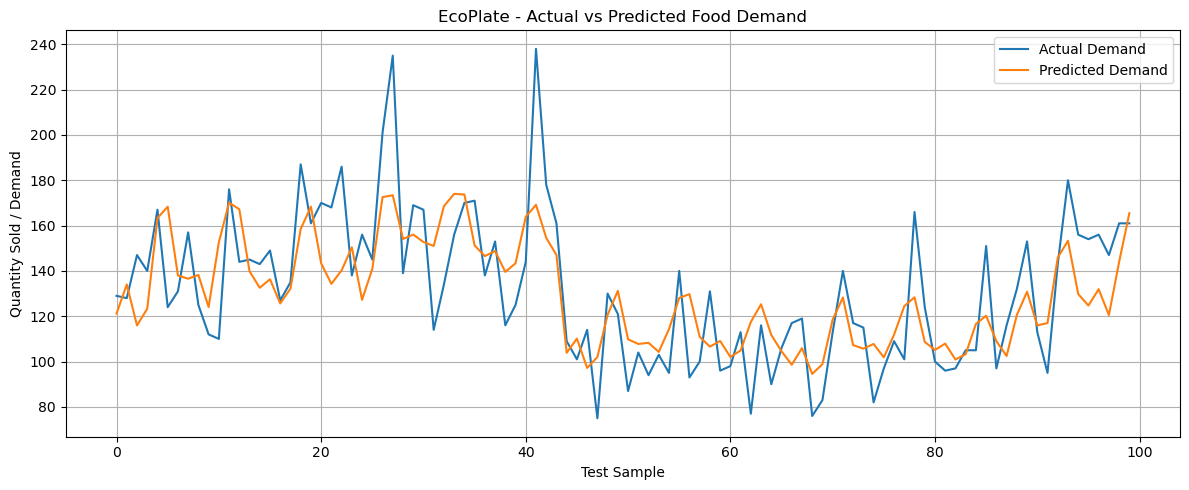

In [19]:
# ============================================================
# ECOPLATE - CELL 15
# Actual vs Predicted Demand
# ============================================================

plot_count = min(100, len(y_test))

plt.figure(figsize=(12, 5))

plt.plot(
    y_test[:plot_count],
    label="Actual Demand"
)

plt.plot(
    y_pred_ecoplate[:plot_count],
    label="Predicted Demand"
)

plt.title(
    "EcoPlate - Actual vs Predicted Food Demand"
)

plt.xlabel("Test Sample")
plt.ylabel("Quantity Sold / Demand")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# ECOPLATE - CELL 16
# Prepare Baseline Data
# ============================================================

# Flatten temporal input for Random Forest
X_train_rf = X_train.reshape(
    X_train.shape[0],
    -1
)

X_val_rf = X_val.reshape(
    X_val.shape[0],
    -1
)

X_test_rf = X_test.reshape(
    X_test.shape[0],
    -1
)

print("=" * 70)
print("BASELINE DATA")
print("=" * 70)

print("Random Forest training:", X_train_rf.shape)
print("Random Forest testing :", X_test_rf.shape)

BASELINE DATA
Random Forest training: (7620, 98)
Random Forest testing : (1293, 98)


In [21]:
# ============================================================
# ECOPLATE - CELL 17
# Random Forest Baseline
# ============================================================

print("=" * 70)
print("TRAINING RANDOM FOREST BASELINE")
print("=" * 70)

rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(
    X_train_rf,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test_rf
)

y_pred_rf = np.maximum(
    y_pred_rf,
    0
)

mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_rf
    )
)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)

print("Random Forest MAE :", round(mae_rf, 3))
print("Random Forest RMSE:", round(rmse_rf, 3))
print("Random Forest R²  :", round(r2_rf, 3))

TRAINING RANDOM FOREST BASELINE
Random Forest MAE : 17.724
Random Forest RMSE: 22.065
Random Forest R²  : 0.579


In [22]:
# ============================================================
# ECOPLATE - CELL 18
# GRU Baseline
# ============================================================

from tensorflow.keras.layers import GRU

gru_input = Input(
    shape=(SEQUENCE_LENGTH, len(sequence_features)),
    name="gru_input"
)

gru_layer = GRU(
    64,
    return_sequences=True
)(gru_input)

gru_layer = GRU(
    32
)(gru_layer)

gru_layer = Dense(
    32,
    activation="relu"
)(gru_layer)

gru_output = Dense(
    1,
    activation="linear"
)(gru_layer)

gru_model = Model(
    inputs=gru_input,
    outputs=gru_output,
    name="GRU_Baseline"
)

gru_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

print("=" * 70)
print("TRAINING GRU BASELINE")
print("=" * 70)

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    callbacks=[
        EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True
        )
    ],
    verbose=1
)

TRAINING GRU BASELINE
Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - loss: 11656.1621 - mae: 102.1841 - val_loss: 9803.7930 - val_mae: 92.9377
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 6705.6729 - mae: 73.8177 - val_loss: 4686.1924 - val_mae: 59.4210
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 2792.4160 - mae: 42.0083 - val_loss: 1876.5103 - val_mae: 32.5054
Epoch 4/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1377.2424 - mae: 28.3120 - val_loss: 1248.9135 - val_mae: 26.9028
Epoch 5/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1184.7485 - mae: 27.0790 - val_loss: 1183.2323 - val_mae: 26.7145
Epoch 6/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1175.6011 - mae: 27.1955 - val_loss: 1176.8679 - val_mae: 26.7455
Epoch 7/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1175.5120 - mae: 27.2250 - val_loss: 1176.0215 - val_mae: 26.7525
Epoch 8/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 1175.5427 - mae: 27.2286 

In [25]:
# ============================================================
# ECOPLATE - CELL 19
# GRU Test Prediction
# ============================================================

y_pred_gru = gru_model.predict(
    X_test,
    verbose=0
).reshape(-1)

y_pred_gru = np.maximum(
    y_pred_gru,
    0
)

mae_gru = mean_absolute_error(
    y_test,
    y_pred_gru
)

rmse_gru = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_gru
    )
)

r2_gru = r2_score(
    y_test,
    y_pred_gru
)

print("=" * 70)
print("GRU TEST RESULTS")
print("=" * 70)

print("MAE  :", round(mae_gru, 3))
print("RMSE :", round(rmse_gru, 3))
print("R²   :", round(r2_gru, 3))

GRU TEST RESULTS
MAE  : 18.693
RMSE : 23.668
R²   : 0.516


In [26]:
# ============================================================
# ECOPLATE - CELL 20
# Previous-Day Demand Baseline
# ============================================================

# Previous_Day_Sales was standardized in X_test.
# Instead, obtain the actual previous-day values from the
# original test sequence data.

previous_day_position = sequence_features.index(
    "Previous_Day_Sales"
)

# Because it was standardized, recover original values
# using the scaler statistics.

previous_day_scaled = X_test[
    :,
    -1,
    previous_day_position
]

# Numerical feature index in scaler
num_index = numerical_features.index(
    "Previous_Day_Sales"
)

previous_day_actual = (
    previous_day_scaled *
    scaler.scale_[num_index]
    +
    scaler.mean_[num_index]
)

y_pred_previous_day = np.maximum(
    previous_day_actual,
    0
)

mae_previous = mean_absolute_error(
    y_test,
    y_pred_previous_day
)

rmse_previous = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_previous_day
    )
)

r2_previous = r2_score(
    y_test,
    y_pred_previous_day
)

print("=" * 70)
print("PREVIOUS-DAY BASELINE")
print("=" * 70)

print("MAE  :", round(mae_previous, 3))
print("RMSE :", round(rmse_previous, 3))
print("R²   :", round(r2_previous, 3))

PREVIOUS-DAY BASELINE
MAE  : 27.076
RMSE : 34.102
R²   : -0.006


In [27]:
# ============================================================
# ECOPLATE - CELL 21
# FINAL MODEL COMPARISON TABLE
# ============================================================

comparison_table = pd.DataFrame({
    
    "Model": [
        "Previous-Day Baseline",
        "Random Forest",
        "GRU",
        "EcoPlate Attention + Gated Temporal"
    ],
    
    "MAE": [
        mae_previous,
        mae_rf,
        mae_gru,
        mae_ecoplate
    ],
    
    "RMSE": [
        rmse_previous,
        rmse_rf,
        rmse_gru,
        rmse_ecoplate
    ],
    
    "R2": [
        r2_previous,
        r2_rf,
        r2_gru,
        r2_ecoplate
    ]
})

comparison_table = comparison_table.round(3)

print("=" * 80)
print("ECOPLATE - MODEL PERFORMANCE COMPARISON")
print("=" * 80)

display(comparison_table)

ECOPLATE - MODEL PERFORMANCE COMPARISON


,Model,MAE,RMSE,R2
0,Previous-Day Baseline,27.076,34.102,-0.006
1,Random Forest,17.724,22.065,0.579
2,GRU,18.693,23.668,0.516
3,EcoPlate Attention + Gated Temporal,17.534,21.339,0.606


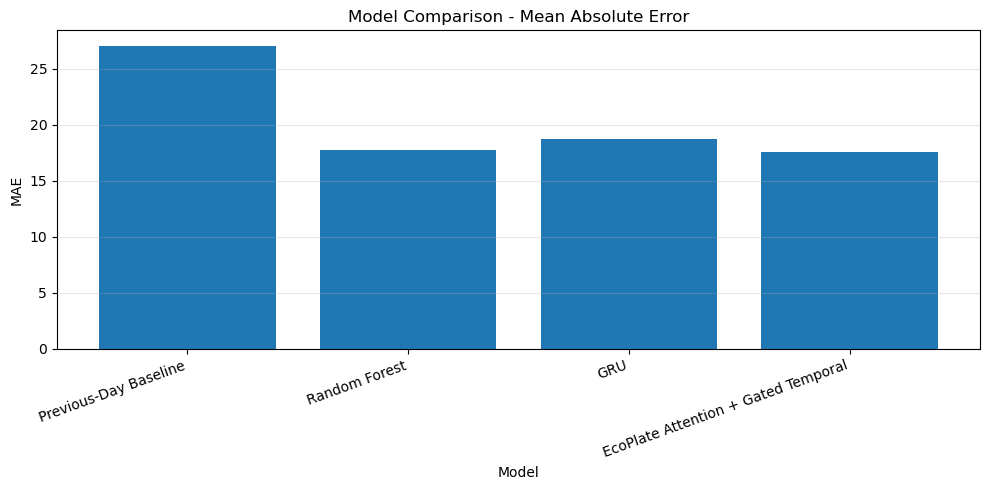

In [28]:
# ============================================================
# ECOPLATE - CELL 22
# Model Comparison Graph
# ============================================================

plt.figure(figsize=(10, 5))

plt.bar(
    comparison_table["Model"],
    comparison_table["MAE"]
)

plt.title(
    "Model Comparison - Mean Absolute Error"
)

plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

In [29]:
# ============================================================
# ECOPLATE - CELL 23
# Identify Best Model
# ============================================================

best_row = comparison_table.loc[
    comparison_table["MAE"].idxmin()
]

print("=" * 70)
print("BEST PERFORMING MODEL")
print("=" * 70)

print("Model:", best_row["Model"])
print("MAE  :", best_row["MAE"])
print("RMSE :", best_row["RMSE"])
print("R²   :", best_row["R2"])

if best_row["Model"] == "EcoPlate Attention + Gated Temporal":
    print("\nEcoPlate proposed model achieved the lowest MAE.")
else:
    print(
        "\nNote: The proposed model did not achieve the lowest MAE "
        "in this particular run. Report the actual comparison honestly."
    )

BEST PERFORMING MODEL
Model: EcoPlate Attention + Gated Temporal
MAE  : 17.534
RMSE : 21.339
R²   : 0.606

EcoPlate proposed model achieved the lowest MAE.


In [30]:
# ============================================================
# ECOPLATE - CELL 24
# Save Model Results
# ============================================================

comparison_table.to_csv(
    "EcoPlate_Model_Comparison.csv",
    index=False
)

print("=" * 70)
print("RESULT SAVED")
print("=" * 70)

print("File: EcoPlate_Model_Comparison.csv")

RESULT SAVED
File: EcoPlate_Model_Comparison.csv


In [46]:
# ============================================================
# ECOPLATE - CELL 25
# RESTAURANT SELECTION
# ============================================================

print("=" * 70)
print("ECOPLATE RESTAURANT SELECTION")
print("=" * 70)

restaurant_list = sorted(
    df["Restaurant_Name"].dropna().unique()
)

for i, restaurant in enumerate(
    restaurant_list,
    start=1
):
    print(f"{i}. {restaurant}")

print("=" * 70)

while True:
    try:
        restaurant_choice = int(
            input("Enter restaurant number: ")
        )
        
        if 1 <= restaurant_choice <= len(restaurant_list):
            break
        
        print("Invalid number. Please choose from the list.")
        
    except ValueError:
        print("Please enter a number only.")

selected_restaurant = restaurant_list[
    restaurant_choice - 1
]

print("\nSelected Restaurant:")
print(selected_restaurant)

ECOPLATE RESTAURANT SELECTION
1. Aroma Kitchen
2. Curry Corner
3. Flavor House
4. Food Junction
5. Grand Dine
6. Heritage Grill
7. Royal Feast
8. Saffron Bowl
9. Spice Hub
10. Urban Tandoor


Enter restaurant number:  1



Selected Restaurant:
Aroma Kitchen


In [47]:
# ============================================================
# ECOPLATE - CELL 26
# MENU ITEM SELECTION
# ============================================================

print("=" * 70)
print("MENU ITEMS")
print("=" * 70)

restaurant_items = sorted(
    df[
        df["Restaurant_Name"] == selected_restaurant
    ]["Menu_Item"]
    .dropna()
    .unique()
)

for i, item in enumerate(
    restaurant_items,
    start=1
):
    print(f"{i}. {item}")

print("=" * 70)

while True:
    try:
        item_choice = int(
            input("Enter menu item number: ")
        )
        
        if 1 <= item_choice <= len(restaurant_items):
            break
        
        print("Invalid number. Please choose from the list.")
        
    except ValueError:
        print("Please enter a number only.")

selected_item = restaurant_items[
    item_choice - 1
]

print("\nSelected Restaurant:")
print(selected_restaurant)

print("Selected Menu Item:")
print(selected_item)

MENU ITEMS
1. Butter Chicken
2. Chicken Biryani
3. Fried Rice
4. Paneer Butter Masala
5. Veg Biryani
6. Veg Meals


Enter menu item number:  3



Selected Restaurant:
Aroma Kitchen
Selected Menu Item:
Fried Rice


In [33]:
# ============================================================
# ECOPLATE - CELL 27
# AUTOMATIC FEATURE RETRIEVAL
# ============================================================

selected_history = df[
    (df["Restaurant_Name"] == selected_restaurant) &
    (df["Menu_Item"] == selected_item)
].sort_values("Date")

if len(selected_history) == 0:
    raise ValueError(
        "No historical records found for this restaurant and item."
    )

latest_record = selected_history.iloc[-1]

print("=" * 70)
print("LATEST AUTOMATIC INPUT FEATURES")
print("=" * 70)

print("Latest Date:", latest_record["Date"])
print("Day:", latest_record["Day_of_Week"])
print("Month:", latest_record["Month"])

print("\nWeather:", latest_record["Weather"])
print("Holiday:", latest_record["Is_Holiday"])
print("Festival:", latest_record["Festival"])

print("\nReservations:", latest_record["Reservations"])
print("Walk-in Customers:", latest_record["Walk_In_Customers"])
print("Previous Day Sales:", latest_record["Previous_Day_Sales"])
print("Average Last 7 Days:", latest_record["Avg_Last_7_Days"])

LATEST AUTOMATIC INPUT FEATURES
Latest Date: 2025-12-16 00:00:00
Day: Tuesday
Month: December

Weather: Sunny
Holiday: 0
Festival: No_Festival

Reservations: 75.0
Walk-in Customers: 123.0
Previous Day Sales: 159.0
Average Last 7 Days: 165.0


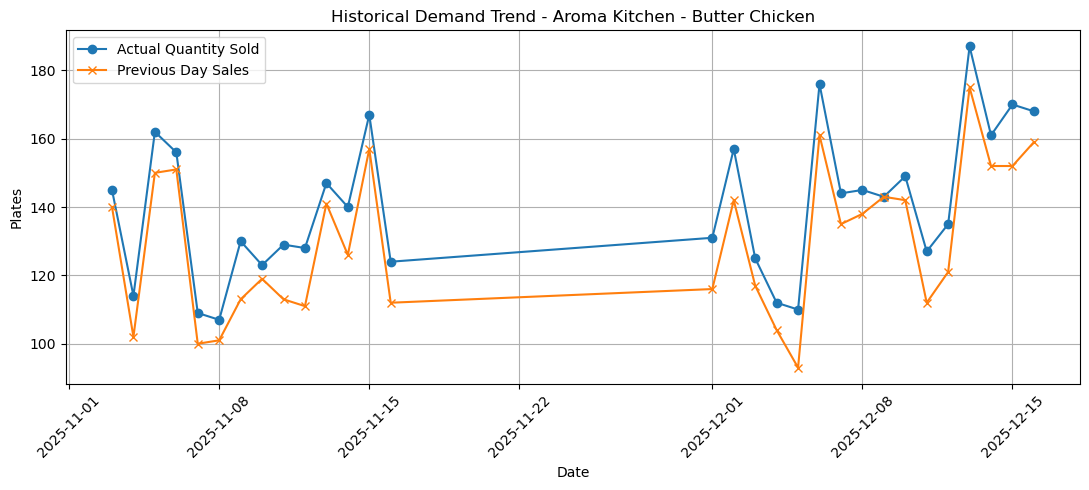

In [34]:
# ============================================================
# ECOPLATE - CELL 28
# HISTORICAL TREND GRAPH
# ============================================================

history_plot = selected_history.tail(30).copy()

plt.figure(figsize=(11, 5))

plt.plot(
    history_plot["Date"],
    history_plot["Quantity_Sold"],
    marker="o",
    label="Actual Quantity Sold"
)

plt.plot(
    history_plot["Date"],
    history_plot["Previous_Day_Sales"],
    marker="x",
    label="Previous Day Sales"
)

plt.title(
    f"Historical Demand Trend - {selected_restaurant} - {selected_item}"
)

plt.xlabel("Date")
plt.ylabel("Plates")

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# ECOPLATE - CELL 29
# Create Latest Prediction Sequence
# ============================================================

# Encode selected restaurant/item history
selected_encoded = encode_categories(
    selected_history.copy()
)

# Normalize numerical values
selected_encoded[numerical_features] = scaler.transform(
    selected_encoded[numerical_features]
)

if len(selected_encoded) < SEQUENCE_LENGTH:
    raise ValueError(
        f"At least {SEQUENCE_LENGTH} historical records "
        "are required for prediction."
    )

latest_sequence = selected_encoded.tail(
    SEQUENCE_LENGTH
)[sequence_features].values.astype(
    np.float32
)

latest_sequence = latest_sequence.reshape(
    1,
    SEQUENCE_LENGTH,
    len(sequence_features)
)

latest_cat = latest_sequence[
    :,
    :,
    categorical_positions
].astype(np.int32)

latest_num = latest_sequence[
    :,
    :,
    numerical_positions
].astype(np.float32)

print("=" * 70)
print("LATEST TEMPORAL WINDOW")
print("=" * 70)

print("Sequence length:", SEQUENCE_LENGTH)
print("Input shape:", latest_sequence.shape)

LATEST TEMPORAL WINDOW
Sequence length: 7
Input shape: (1, 7, 14)


In [36]:
# ============================================================
# ECOPLATE - CELL 30
# DEMAND PREDICTION
# ============================================================

predicted_demand = model.predict(
    [
        latest_cat,
        latest_num
    ],
    verbose=0
)[0][0]

predicted_demand = max(
    0,
    float(predicted_demand)
)

predicted_demand_plates = int(
    round(predicted_demand)
)

print("=" * 70)
print("DEMAND PREDICTION")
print("=" * 70)

print("Restaurant:", selected_restaurant)
print("Menu Item:", selected_item)

print("\nPredicted Demand:")
print(predicted_demand_plates, "plates")

DEMAND PREDICTION
Restaurant: Aroma Kitchen
Menu Item: Butter Chicken

Predicted Demand:
135 plates


In [37]:
# ============================================================
# ECOPLATE - CELL 31
# FOOD TYPE
# ============================================================

def detect_food_type(item):
    
    item_lower = str(item).lower()
    
    nonveg_words = [
        "chicken",
        "mutton",
        "fish",
        "prawn",
        "prawns",
        "egg",
        "beef",
        "lamb",
        "meat",
        "biryani"
    ]
    
    for word in nonveg_words:
        if word in item_lower:
            return "Non-Veg"
    
    return "Veg"


food_type = detect_food_type(
    selected_item
)

print("=" * 70)
print("FOOD TYPE")
print("=" * 70)

print("Menu Item:", selected_item)
print("Food Type:", food_type)

FOOD TYPE
Menu Item: Butter Chicken
Food Type: Non-Veg


In [38]:
# ============================================================
# ECOPLATE - CELL 32
# SURPLUS DECISION ENGINE
# ============================================================

EXTRA_PLATES_POLICY = 10

recommended_preparation = (
    predicted_demand_plates +
    EXTRA_PLATES_POLICY
)

expected_leftover = max(
    0,
    recommended_preparation -
    predicted_demand_plates
)

print("=" * 70)
print("SURPLUS DECISION ENGINE")
print("=" * 70)

print("Predicted Demand       :", predicted_demand_plates)
print("Extra Plates Policy    :", EXTRA_PLATES_POLICY)
print("Recommended Preparation:",
      recommended_preparation)
print("Expected Leftover      :",
      expected_leftover)

SURPLUS DECISION ENGINE
Predicted Demand       : 135
Extra Plates Policy    : 10
Recommended Preparation: 145
Expected Leftover      : 10


In [39]:
# ============================================================
# ECOPLATE - CELL 33
# NGO PREPARATION
# ============================================================

ngo["Capacity_Meals"] = pd.to_numeric(
    ngo["Capacity_Meals"],
    errors="coerce"
)

ngo["Availability"] = (
    ngo["Availability"]
    .astype(str)
    .str.lower()
    .str.strip()
)

ngo["Food_Type_Accepted"] = (
    ngo["Food_Type_Accepted"]
    .astype(str)
    .str.lower()
    .str.strip()
)

ngo["Capacity_Meals"] = ngo[
    "Capacity_Meals"
].fillna(0)

print("=" * 70)
print("NGO DATA")
print("=" * 70)

print("Number of NGOs:", len(ngo))

display(
    ngo[
        [
            "NGO_ID",
            "NGO_Name",
            "Area",
            "Capacity_Meals",
            "Food_Type_Accepted",
            "Availability"
        ]
    ]
)

NGO DATA
Number of NGOs: 15


,NGO_ID,NGO_Name,Area,Capacity_Meals,Food_Type_Accepted,Availability
0,NGO001,Robin Hood Army Hyderabad,Madhapur,300,all,yes
1,NGO002,Feeding Hands Foundation,Gachibowli,250,veg & non-veg,yes
2,NGO003,Akshaya Patra Foundation,Kukatpally,500,veg,yes
3,NGO004,Hunger Relief Trust,Hitech City,220,all,yes
4,NGO005,Care & Share Foundation,Banjara Hills,180,veg,yes
5,NGO006,Helping Hands NGO,Kondapur,240,all,yes
6,NGO007,Annapurna Food Bank,Begumpet,350,veg & non-veg,yes
7,NGO008,Smile Foundation,Ameerpet,200,veg,yes
8,NGO009,Zero Hunger Hyderabad,Miyapur,280,all,yes
9,NGO010,Food For All Trust,Secunderabad,260,all,yes


In [40]:
# ============================================================
# ECOPLATE - CELL 34
# NGO FILTERING AND RANKING
# ============================================================

def food_type_match(accepted, food_type):
    
    accepted = str(accepted).lower()
    food_type = str(food_type).lower()
    
    if "both" in accepted:
        return 1
    
    if food_type == "veg" and "veg" in accepted:
        return 1
    
    if food_type == "non-veg" and "non" in accepted:
        return 1
    
    return 0


ngo["Food_Match"] = ngo[
    "Food_Type_Accepted"
].apply(
    lambda x: food_type_match(
        x,
        food_type
    )
)

# Available NGOs
available_ngo = ngo[
    ngo["Availability"].isin(
        ["yes", "available", "true", "1"]
    )
].copy()

# If no exact availability labels match,
# use all NGOs with matching food type.
if len(available_ngo) == 0:
    available_ngo = ngo.copy()

available_ngo["Food_Match"] = available_ngo[
    "Food_Type_Accepted"
].apply(
    lambda x: food_type_match(
        x,
        food_type
    )
)

matching_ngo = available_ngo[
    available_ngo["Food_Match"] == 1
].copy()

if len(matching_ngo) == 0:
    matching_ngo = available_ngo.copy()

# Capacity suitability
matching_ngo["Capacity_Difference"] = abs(
    matching_ngo["Capacity_Meals"] -
    expected_leftover
)

# Prefer the smallest capacity that can handle the surplus.
capacity_suitable = matching_ngo[
    matching_ngo["Capacity_Meals"] >= expected_leftover
].copy()

if len(capacity_suitable) > 0:
    
    ranked_ngo = capacity_suitable.sort_values(
        by=[
            "Capacity_Difference"
        ],
        ascending=True
    )
    
else:
    # If no NGO can fully handle it,
    # choose the NGO with the largest capacity.
    ranked_ngo = matching_ngo.sort_values(
        by="Capacity_Meals",
        ascending=False
    )

recommended_ngo = ranked_ngo.iloc[0]

print("=" * 70)
print("NGO RECOMMENDATION")
print("=" * 70)

print("NGO:", recommended_ngo["NGO_Name"])
print("Area:", recommended_ngo["Area"])
print("Capacity:", recommended_ngo["Capacity_Meals"])
print("Accepted Food:", recommended_ngo["Food_Type_Accepted"])
print("Availability:", recommended_ngo["Availability"])

NGO RECOMMENDATION
NGO: Feeding Hands Foundation
Area: Gachibowli
Capacity: 250
Accepted Food: veg & non-veg
Availability: yes


In [41]:
# ============================================================
# ECOPLATE - CELL 35
# FINAL ECOPLATE RECOMMENDATION
# ============================================================

final_result = pd.DataFrame({
    
    "Restaurant": [
        selected_restaurant
    ],
    
    "Menu Item": [
        selected_item
    ],
    
    "Food Type": [
        food_type
    ],
    
    "Predicted Demand (plates)": [
        predicted_demand_plates
    ],
    
    "Recommended Preparation (plates)": [
        recommended_preparation
    ],
    
    "Expected Leftover (plates)": [
        expected_leftover
    ],
    
    "NGO": [
        recommended_ngo["NGO_Name"]
    ],
    
    "NGO Area": [
        recommended_ngo["Area"]
    ],
    
    "NGO Capacity": [
        int(recommended_ngo["Capacity_Meals"])
    ],
    
    "Distance": [
        "Unavailable"
    ],
    
    "Status": [
        "RECOMMENDED - DISTANCE UNAVAILABLE"
    ]
})

print("=" * 90)
print("                    ECOPLATE FINAL RESULT")
print("=" * 90)

display(final_result)

                    ECOPLATE FINAL RESULT


,Restaurant,Menu Item,Food Type,Predicted Demand (plates),Recommended Preparation (plates),Expected Leftover (plates),NGO,NGO Area,NGO Capacity,Distance,Status
0,Aroma Kitchen,Butter Chicken,Non-Veg,135,145,10,Feeding Hands Foundation,Gachibowli,250,Unavailable,RECOMMENDED - DISTANCE UNAVAILABLE


In [42]:
# ============================================================
# ECOPLATE - CELL 36
# NGO RANKING TABLE
# ============================================================

ngo_display = ranked_ngo[
    [
        "NGO_ID",
        "NGO_Name",
        "Area",
        "Capacity_Meals",
        "Food_Type_Accepted",
        "Availability",
        "Capacity_Difference"
    ]
].copy()

ngo_display = ngo_display.head(10)

ngo_display = ngo_display.rename(
    columns={
        "Capacity_Meals": "Capacity",
        "Food_Type_Accepted": "Food Type Accepted",
        "Capacity_Difference": "Capacity Difference"
    }
)

print("=" * 80)
print("TOP NGO CANDIDATES")
print("=" * 80)

display(ngo_display)

TOP NGO CANDIDATES


,NGO_ID,NGO_Name,Area,Capacity,Food Type Accepted,Availability,Capacity Difference
1,NGO002,Feeding Hands Foundation,Gachibowli,250,veg & non-veg,yes,240
11,NGO012,Community Food Bank,Uppal,300,veg & non-veg,yes,290
6,NGO007,Annapurna Food Bank,Begumpet,350,veg & non-veg,yes,340


In [43]:
# ============================================================
# ECOPLATE - CELL 37
# COMPLETE PERFORMANCE SUMMARY
# ============================================================

print("=" * 80)
print("                 ECOPLATE COMPLETE SUMMARY")
print("=" * 80)

print("\nDATASET")
print("-" * 80)
print("Restaurant records :", len(df))
print("NGO records        :", len(ngo))
print("Restaurants        :", df["Restaurant_Name"].nunique())
print("Menu items         :", df["Menu_Item"].nunique())

print("\nMODEL")
print("-" * 80)
print("Architecture:")
print("Categorical Embeddings")
print("        ↓")
print("Numerical Feature Projection")
print("        ↓")
print("Multi-Head Attention")
print("        ↓")
print("Gated Temporal GRU")
print("        ↓")
print("Demand Prediction")

print("\nTEST PERFORMANCE")
print("-" * 80)
print("EcoPlate MAE :", round(mae_ecoplate, 3))
print("EcoPlate RMSE:", round(rmse_ecoplate, 3))
print("EcoPlate R²  :", round(r2_ecoplate, 3))

print("\nSELECTED ITEM")
print("-" * 80)
print("Restaurant        :", selected_restaurant)
print("Menu Item         :", selected_item)
print("Food Type         :", food_type)
print("Predicted Demand  :", predicted_demand_plates)
print("Recommended Prep  :", recommended_preparation)
print("Expected Leftover  :", expected_leftover)

print("\nNGO")
print("-" * 80)
print("NGO               :", recommended_ngo["NGO_Name"])
print("Area              :", recommended_ngo["Area"])
print("Capacity          :", recommended_ngo["Capacity_Meals"])

print("\nSTATUS")
print("-" * 80)
print("Recommendation generated successfully.")

                 ECOPLATE COMPLETE SUMMARY

DATASET
--------------------------------------------------------------------------------
Restaurant records : 11493
NGO records        : 15
Restaurants        : 10
Menu items         : 6

MODEL
--------------------------------------------------------------------------------
Architecture:
Categorical Embeddings
        ↓
Numerical Feature Projection
        ↓
Multi-Head Attention
        ↓
Gated Temporal GRU
        ↓
Demand Prediction

TEST PERFORMANCE
--------------------------------------------------------------------------------
EcoPlate MAE : 17.534
EcoPlate RMSE: 21.339
EcoPlate R²  : 0.606

SELECTED ITEM
--------------------------------------------------------------------------------
Restaurant        : Aroma Kitchen
Menu Item         : Butter Chicken
Food Type         : Non-Veg
Predicted Demand  : 135
Recommended Prep  : 145
Expected Leftover  : 10

NGO
--------------------------------------------------------------------------------
NG